In [27]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Charger les données MNIST
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Prétraiter les données
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# Construire le modèle
model = Sequential([
	Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
	MaxPooling2D((2, 2)),
	Conv2D(64, (3, 3), activation='relu'),
	MaxPooling2D((2, 2)),
	Conv2D(64, (3, 3), activation='relu'),
	Flatten(),
	Dense(64, activation='relu'),
	Dense(10, activation='softmax')
])

# Compiler le modèle
model.compile(optimizer='adam',
			  loss='categorical_crossentropy',
			  metrics=['accuracy'])

# Configuration de l'Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Surveille la perte de validation
    patience=3,  # Nombre d'époques sans amélioration après lesquelles l'entraînement sera arrêté
    verbose=1,
    restore_best_weights=True  # Restaure les meilleurs poids trouvés
)


# Entraîner le modèle avec un ensemble de validation
historique = model.fit(train_images, train_labels, epochs=20, batch_size=64, 
					   validation_split=0.1,  # Ajout de cette ligne
					   callbacks=[early_stopping])

# Le reste du code reste inchangé

# Évaluer le modèle
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc}")

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8746 - loss: 0.4334 - val_accuracy: 0.9848 - val_loss: 0.0527
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9828 - loss: 0.0558 - val_accuracy: 0.9897 - val_loss: 0.0396
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9870 - loss: 0.0390 - val_accuracy: 0.9887 - val_loss: 0.0416
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9910 - loss: 0.0281 - val_accuracy: 0.9908 - val_loss: 0.0335
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9927 - loss: 0.0226 - val_accuracy: 0.9912 - val_loss: 0.0289
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9937 - loss: 0.0187 - val_accuracy: 0.9928 - val_loss: 0.0290
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9955 - loss: 0.0140 - val_accuracy: 0.9922 - val_loss: 0.0309
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9959 - loss: 0.0127 - val_acc

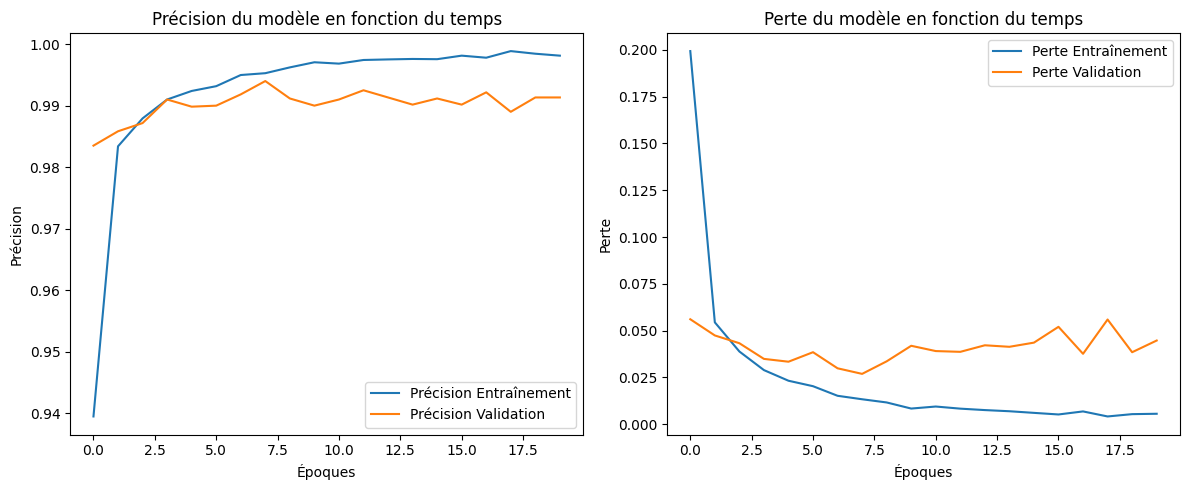

In [26]:
from utils import plot

plot(historique)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


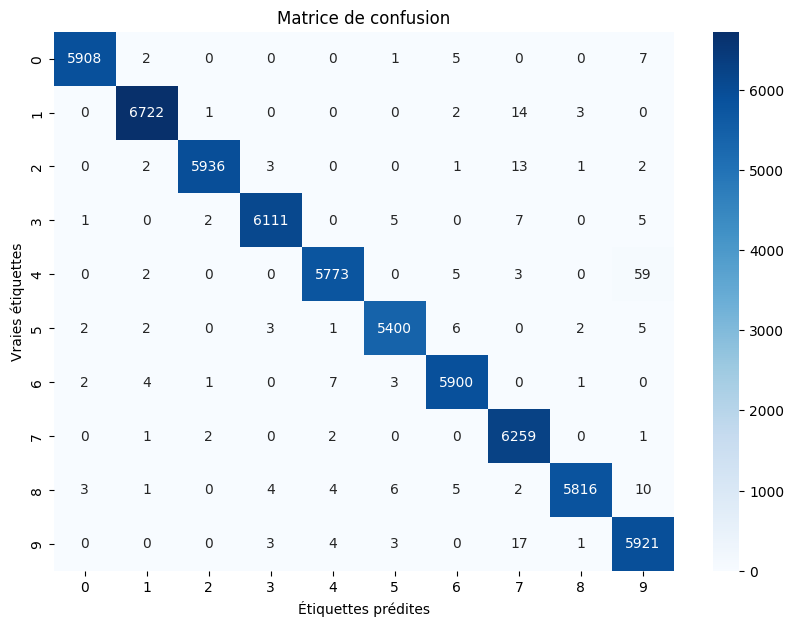

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Prédire les étiquettes des données de test
y_pred = model.predict(train_images)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(train_labels, axis=1)

# Calculer la matrice de confusion
conf_matrix = confusion_matrix(y_true, y_pred_classes)

target_names = range(10)

# Afficher la matrice de confusion
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Matrice de confusion")
plt.ylabel('Vraies étiquettes')
plt.xlabel('Étiquettes prédites')
plt.show()